In [1]:
# Library Imports

import os
import json
import random
from PIL import Image
from test_utils import *
from models import build_model
import matplotlib.pyplot as plt

/data/gpfs/projects/punim1800/detr-mod/env-cu11/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
CLASSES = ["D00", "D10", "D20", "D40"]

data_root = '/data/gpfs/projects/punim1800/RDD-2022/holdout/coco_holdout/'
set_name = 'test2017'
model_dir = 'outputs/holdout_00/'

annotations_path = os.path.join(
    data_root, 'annotations/instances_{}.json'.format(set_name))

In [31]:
thresh = 0.5

In [8]:
model_path = model_dir + 'checkpoint.pth'
model = load_model_from_ckp(model_path)

Building a DETR model with 5 classes


In [32]:
file_name = None

# Load Annotations

with open(annotations_path, 'r') as f:
    annotations = json.load(f)

images = annotations['images']
image = random.choice(images)
if not file_name:
    file_name = image['file_name']
    image_id = image['id']
    print('file_name: ', file_name)
else:
    image_id = get_image_id(file_name)

# get annotations for the image_id
annotations = [a for a in annotations['annotations'] if a['image_id'] == image_id]

# load image and plot annotations in image
image_path = os.path.join(data_root, set_name, file_name)

im = Image.open(image_path)

# mean-std normalize the input image (batch-size: 1)
img = transform(im).unsqueeze(0)

# propagate through the model
outputs = model(img)

# keep only predictions with thresh+ confidence
probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
keep = probas.max(-1).values > thresh

# convert all boxes to image scales
bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0, :], im.size)

file_name:  Norway_002780.jpg


In [35]:
pred_data_path = 'outputs/holdout_00/predictions.json'

# If you want to use pre-calculated model outputs, load them from the JSON file
with open(pred_data_path, 'r') as f:
    pred_data = json.load(f)

IndexError: list index out of range

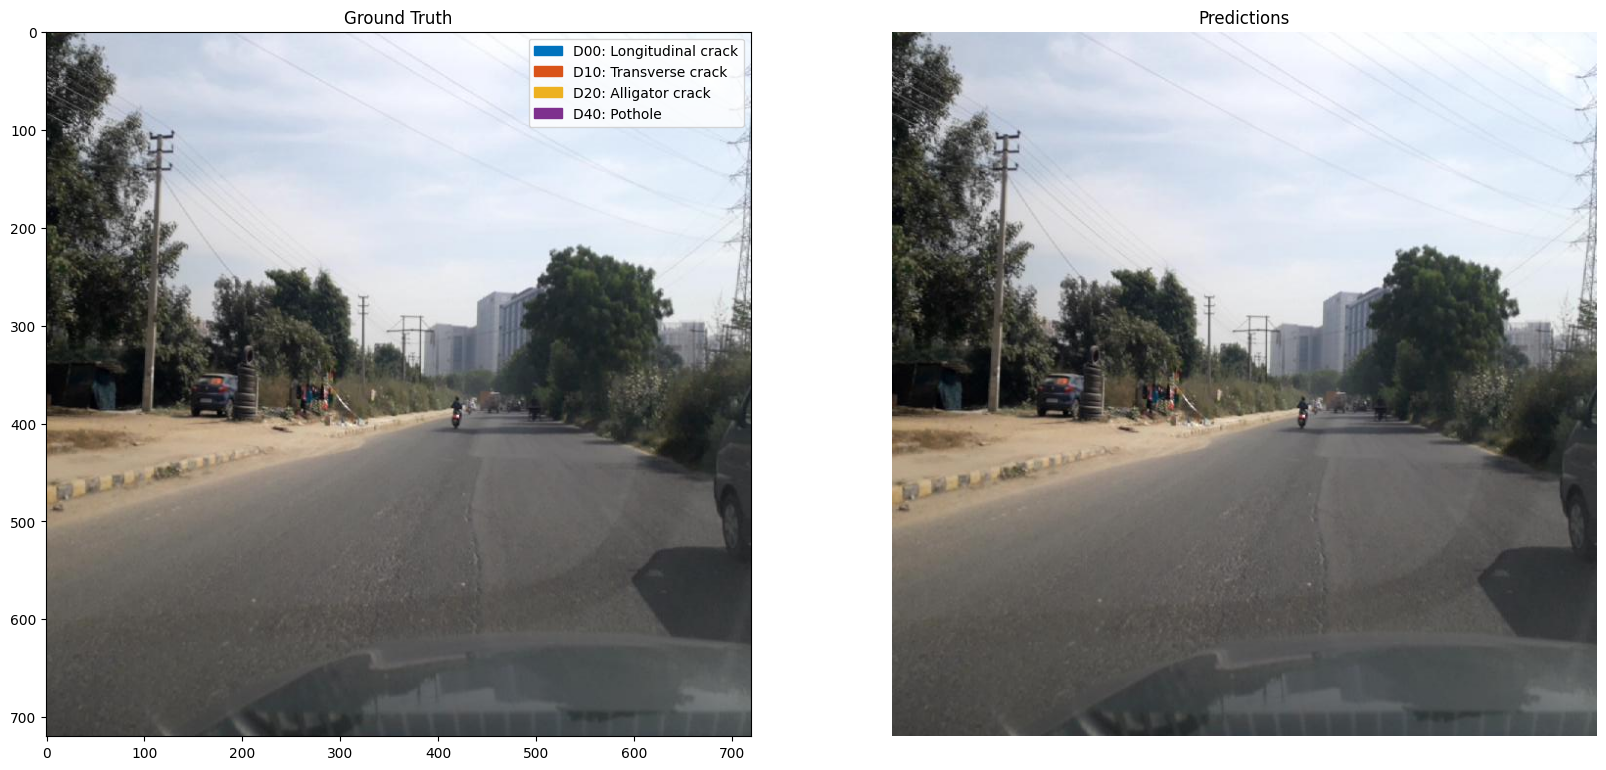

In [39]:
# Plot the predicted bounding boxes along with the probability of the predicted class

import matplotlib.pyplot as plt
import matplotlib.patches as patches

colors = COLORS * 100

#ax = plt.gca()

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(im)
ax[0].set_title('Ground Truth')

for a in annotations:
    x, y, w, h = a['bbox']
    #print(a['category_id'])
    #class_name = CLASS_NAMES[a['category_id']]
    class_code = CLASSES[a['category_id']]
    color = colors[a['category_id']]
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
    ax[0].add_patch(rect)
    ax[0].text(x, y, class_code, bbox={'facecolor': color, 'alpha': 0.5})
ax[0].legend(handles=[patches.Patch(color=color, label=class_name) for class_name, color in zip(CLASS_NAMES.values(), colors)])    
plt.axis('off')

ax[1].imshow(im)
ax[1].set_title('Predictions')

for i in range(len(keep)):
    if keep[i]:
        bbox = bboxes_scaled[i]
        prob = probas[i]
        class_id = prob.argmax()
        class_name = CLASSES[class_id]
        prob = prob[class_id]*100
        color = colors[class_id]
        rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1], linewidth=1, edgecolor=color, facecolor='none')
        ax[1].add_patch(rect)
        ax[1].text(bbox[0], bbox[1], '{}: {:.0f} %'.format(class_name, prob), color=color, bbox=dict(facecolor='white', alpha=0.5))

# plot legend including CLASS_NAMES

ax[1].legend(handles=[patches.Patch(color=color, label=class_name) for class_name, color in zip(CLASS_NAMES.values(), colors)])    
plt.axis('off')

plt.show()

In [40]:
file_name = None

# Load Annotations

with open(annotations_path, 'r') as f:
    annotations = json.load(f)

images = annotations['images']
image = random.choice(images)
if not file_name:
    file_name = image['file_name']
    image_id = image['id']
    print('file_name: ', file_name)
else:
    image_id = get_image_id(file_name)

# get annotations for the image_id
annotations = [a for a in annotations['annotations'] if a['image_id'] == image_id]

# load image and plot annotations in image
image_path = os.path.join(data_root, set_name, file_name)

im = Image.open(image_path)

# mean-std normalize the input image (batch-size: 1)
img = transform(im).unsqueeze(0)

# Extract relevant predictions for the chosen image_id from pred_data
predictions_for_image = [p for p in pred_data if p['image_id'] == image_id]

# Filter predictions based on confidence score (assuming 'thresh' is defined somewhere in the code)
predictions_for_image = [p for p in predictions_for_image if p['score'] > thresh]

file_name:  United_States_000160.jpg


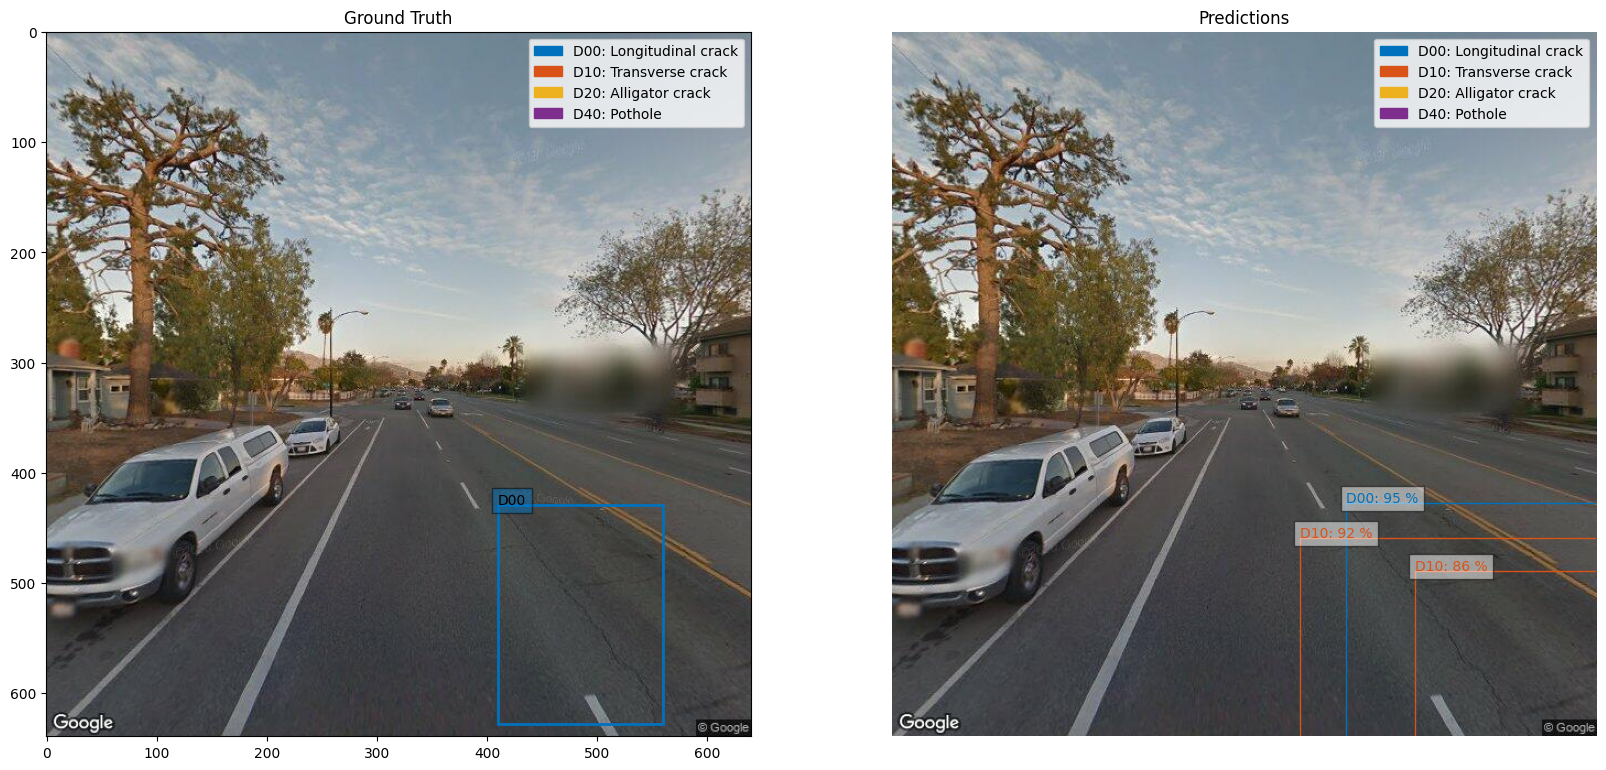

In [41]:
# Plot the predicted bounding boxes along with the probability of the predicted class

import matplotlib.pyplot as plt
import matplotlib.patches as patches

colors = COLORS * 100

#ax = plt.gca()

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(im)
ax[0].set_title('Ground Truth')

for a in annotations:
    x, y, w, h = a['bbox']
    #print(a['category_id'])
    #class_name = CLASS_NAMES[a['category_id']]
    class_code = CLASSES[a['category_id']]
    color = colors[a['category_id']]
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
    ax[0].add_patch(rect)
    ax[0].text(x, y, class_code, bbox={'facecolor': color, 'alpha': 0.5})
ax[0].legend(handles=[patches.Patch(color=color, label=class_name) for class_name, color in zip(CLASS_NAMES.values(), colors)])    
plt.axis('off')

ax[1].imshow(im)
ax[1].set_title('Predictions')

for p in predictions_for_image:
    x, y, w, h = p['bbox']
    class_id = p['category_id']
    prob = p['score']*100
    class_name = CLASSES[class_id]
    color = colors[class_id]
    rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor=color, facecolor='none')
    ax[1].add_patch(rect)
    ax[1].text(x, y, '{}: {:.0f} %'.format(class_name, prob), color=color, bbox=dict(facecolor='white', alpha=0.5))

# plot legend including CLASS_NAMES

ax[1].legend(handles=[patches.Patch(color=color, label=class_name) for class_name, color in zip(CLASS_NAMES.values(), colors)])    
plt.axis('off')

plt.show()